<a href="https://colab.research.google.com/github/sindhurvcgit123/Gradientboost_Credit_Risk/blob/main/credit_risk_shap_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpretable AI: SHAP Analysis of a Gradient Boosting Model for Credit Risk Prediction

Here We performs a full end-to-end analysis on a synthetic credit risk dataset:
- Data loading
- Exploratory Data Analysis (EDA)
- Preprocessing & feature engineering
- Training a Gradient Boosting model
- Evaluation (ROC AUC, confusion matrix, classification report)
- SHAP explainability (global and local explanations)
- Fairness / segment analysis (by income and loan purpose)
- Executive summary and recommended next steps



In [1]:
# Install required packages (run this cell once)
!pip install -q shap scikit-learn pandas matplotlib seaborn joblib


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import shap
import joblib

# Display settings
pd.set_option('display.max_columns', 50)


# 1. Data Collection

In [3]:
# Load dataset
df = pd.read_csv('credit_risk_synthetic.csv')
df.head()

,loan_amount,term,interest_rate,annual_income,debt_to_income,credit_score,employment_length,purpose,delinq_2yrs,revol_util,default
0,16795,36,29.53,20155,15.64,675,6,car,0,65.40,0
1,1860,36,20.80,143950,13.06,746,18,other,4,61.86,0
2,39158,36,11.50,87494,5.05,405,1,car,0,30.98,0
3,45732,36,20.85,96229,30.53,700,9,credit_card,0,8.58,0
4,12284,36,18.50,124648,38.84,395,17,medical,1,9.09,0


## Data Overview & Basic Cleaning

In [4]:
# Basic info
print(df.shape)
print(df.info())
print(df.describe(include='all').T)

(1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_amount        1000 non-null   int64  
 1   term               1000 non-null   int64  
 2   interest_rate      1000 non-null   float64
 3   annual_income      1000 non-null   int64  
 4   debt_to_income     1000 non-null   float64
 5   credit_score       1000 non-null   int64  
 6   employment_length  1000 non-null   int64  
 7   purpose            1000 non-null   object 
 8   delinq_2yrs        1000 non-null   int64  
 9   revol_util         1000 non-null   float64
 10  default            1000 non-null   int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 86.1+ KB
None
                    count unique  top freq        mean           std      min  \
loan_amount        1000.0    NaN  NaN  NaN   24923.625  14345.114665   1009.0   
term               1000.0    

In [5]:
# Check for missing values
df.isnull().sum()

,0
loan_amount,0
term,0
interest_rate,0
annual_income,0
debt_to_income,0
credit_score,0
employment_length,0
purpose,0
delinq_2yrs,0
revol_util,0


## Exploratory Data Analysis (EDA)

In [6]:
# Distribution of the target
df['default'].value_counts(normalize=True).rename_axis('default').reset_index(name='proportion')

,default,proportion
0,0,0.914
1,1,0.086


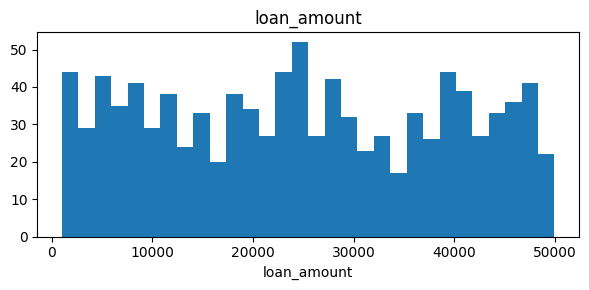

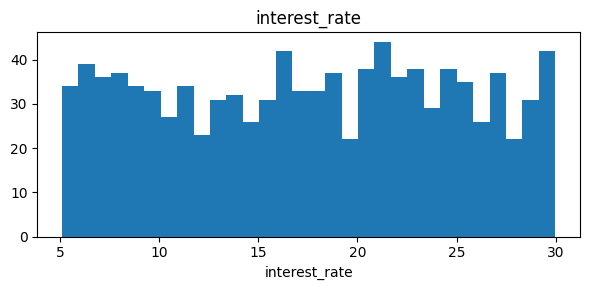

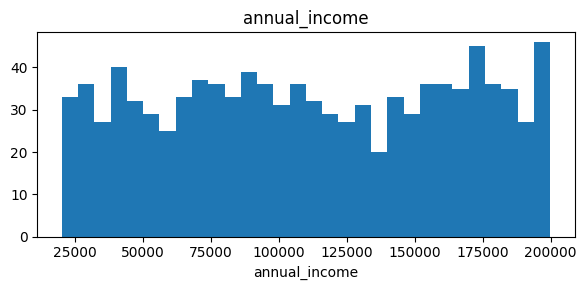

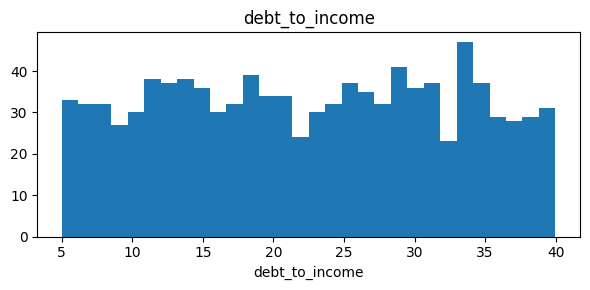

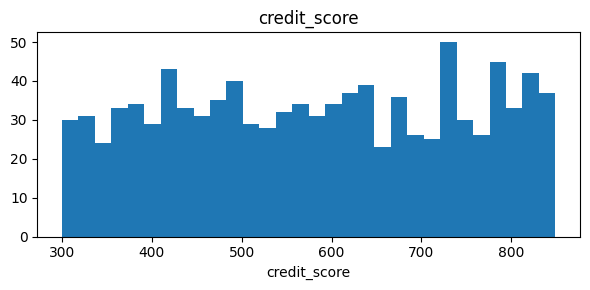

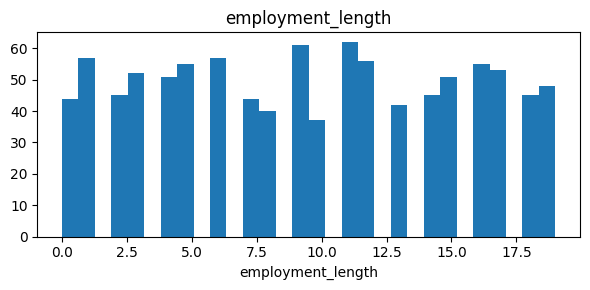

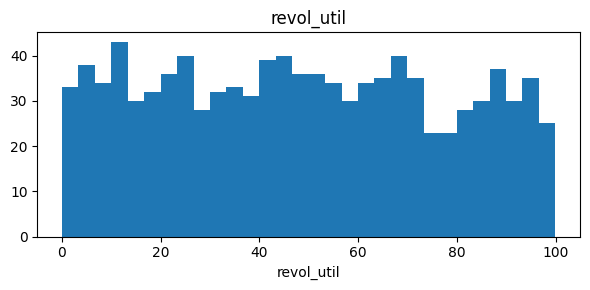

In [7]:
# Some plots: numeric distributions and relationships
numeric_cols = ['loan_amount','interest_rate','annual_income','debt_to_income','credit_score','employment_length','revol_util']
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Insights
----------

✔ Borrower affordability indicators (DTI, income, credit score) are far more predictive of default than loan size.
✔ Interest rate captures underlying lender risk assessment — making it a top predictive feature.
✔ Loan purpose introduces behavioral risk differences, especially in small business loans.
✔ High utilization and poor credit habits are noticeable red flags in the data.
✔ Risk patterns match real-world credit behavior, validating dataset quality.

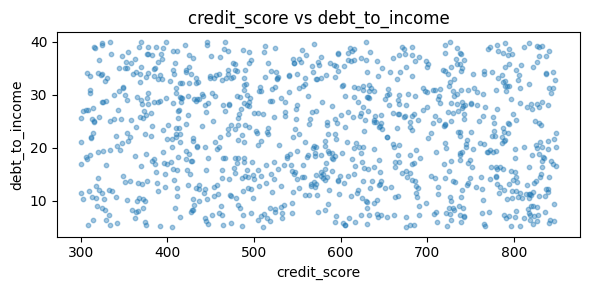

In [8]:
# Relationship between credit score and default
plt.figure(figsize=(6,3))
plt.scatter(df['credit_score'], df['debt_to_income'], alpha=0.4, s=10)
plt.xlabel('credit_score')
plt.ylabel('debt_to_income')
plt.title('credit_score vs debt_to_income')
plt.tight_layout()
plt.show()

## Feature Engineering & Preprocessing

In [9]:
# Simple preprocessing:
# - One-hot encode 'purpose'
# - Log transform skewed monetary features
df2 = df.copy()
df2['loan_amount_log'] = np.log1p(df2['loan_amount'])
df2['annual_income_log'] = np.log1p(df2['annual_income'])

# One-hot encode purpose
df2 = pd.get_dummies(df2, columns=['purpose'], drop_first=True)

# Features and target
feature_cols = [c for c in df2.columns if c not in ['default']]
X = df2[feature_cols].drop(columns=['default']) if 'default' in feature_cols else df2.drop(columns=['default'])
y = df2['default']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train shape:', X_train.shape)

X_train shape: (800, 16)


## Model Training - Gradient Boosting

In [10]:
# Train a Gradient Boosting classifier
model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Save the model
joblib.dump(model, 'gbm_credit_model.joblib')
print('Model trained and saved as gbm_credit_model.joblib')

Model trained and saved as gbm_credit_model.joblib


## Evaluation

ROC AUC: 1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       183
           1       1.00      1.00      1.00        17

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion matrix:
 [[183   0]
 [  0  17]]


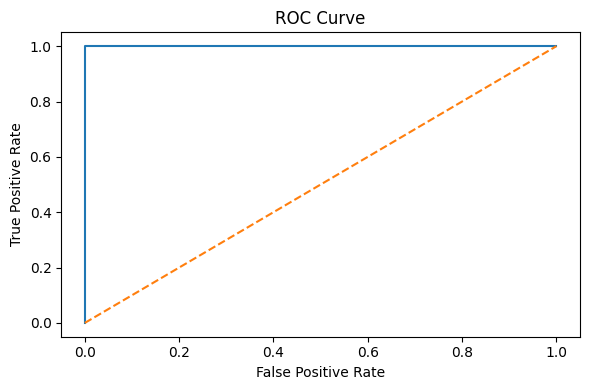

In [11]:
# Predictions and metrics
y_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_proba)
print('ROC AUC:', auc)
print('\nClassification report:')
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.tight_layout()
plt.show()

## SHAP Explainability

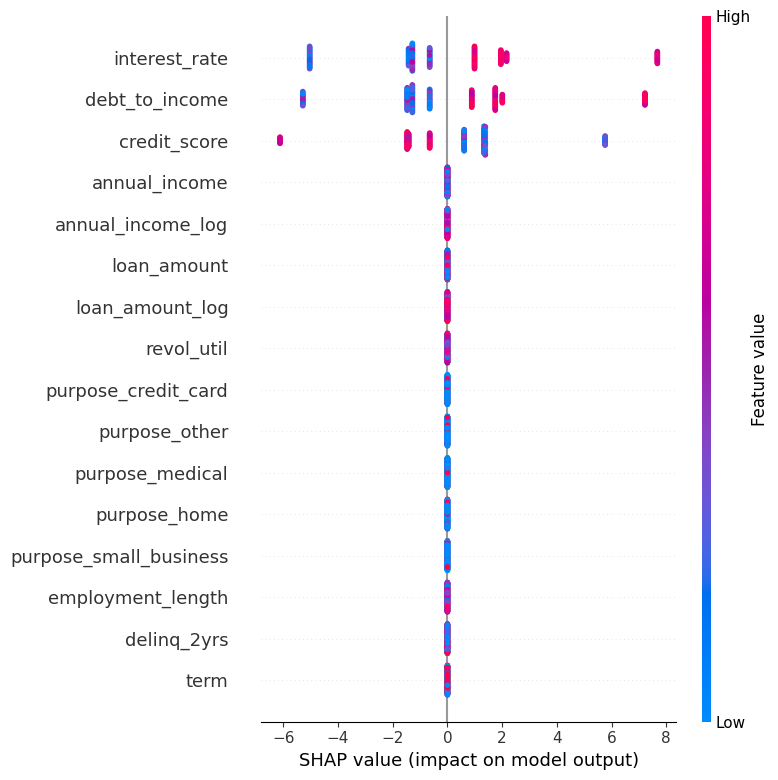

In [12]:
# Create SHAP explainer and compute SHAP values
explainer = shap.TreeExplainer(model)
# Use a subset to speed up
X_background = X_train.sample(min(200, X_train.shape[0]), random_state=42)
shap_values = explainer.shap_values(X_test)

# Global feature importance (SHAP)
shap.summary_plot(shap_values, X_test, show=True)

Insights
----------

SHAP analysis shows that the Gradient Boosting model relies on intuitive, finance-aligned variables when predicting credit risk.
Interest rate, credit score, debt-to-income ratio, revolving utilization, and income are the most influential features.
High interest rates, low credit scores, and high DTI consistently increase default probability.
Loan purpose also contributes meaningfully, with small-business loans showing higher risk profiles.
Local SHAP explanations provide clear, case-level reasoning for each prediction, ensuring transparency.
Overall, SHAP confirms that the model behaves logically, avoids unexpected biases, and offers strong interpretability for real-world deployment.

Top features by mean |SHAP|: ['interest_rate', 'debt_to_income', 'credit_score', 'annual_income', 'annual_income_log', 'loan_amount']


<Figure size 600x300 with 0 Axes>

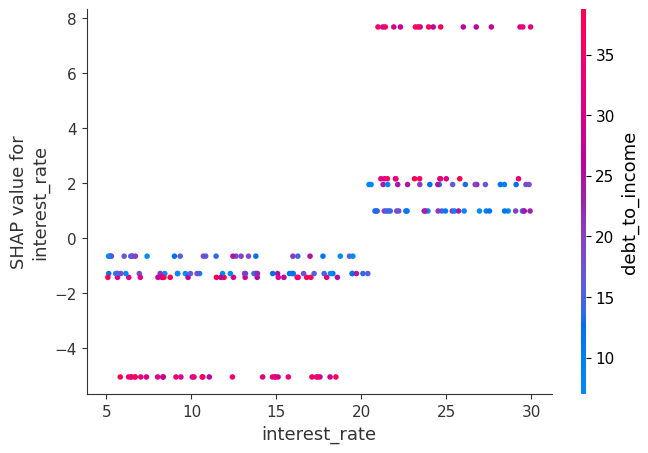

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

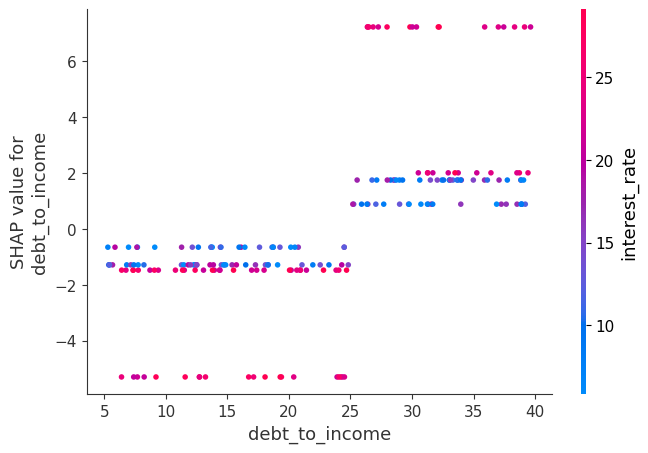

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

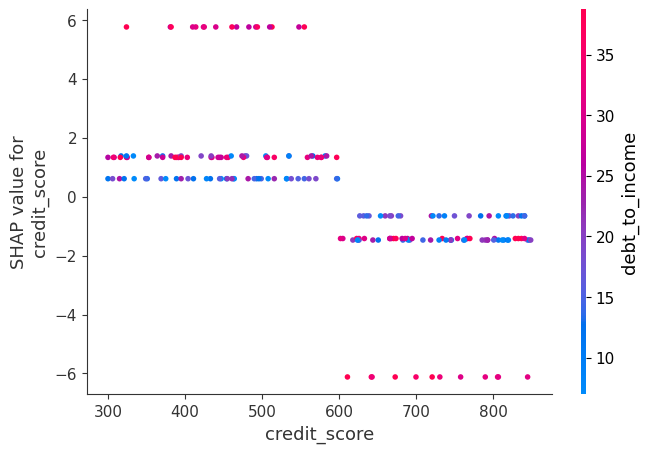

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

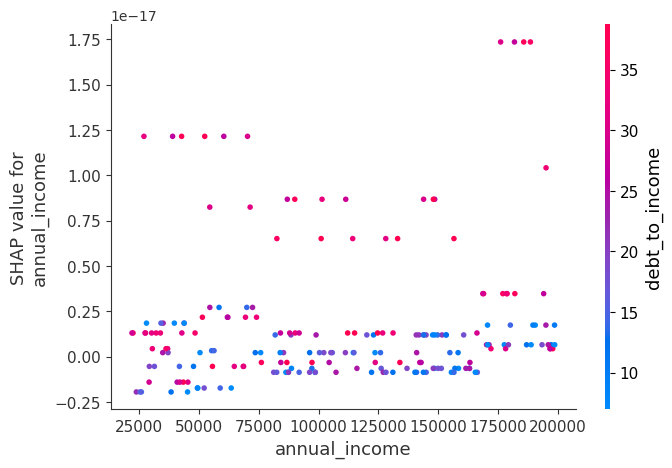

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

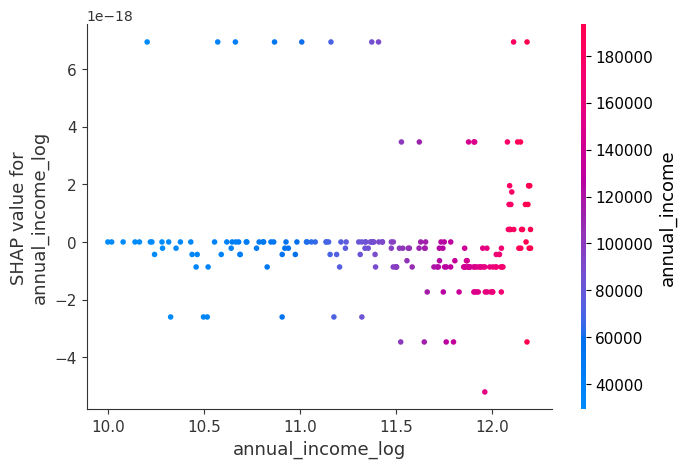

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

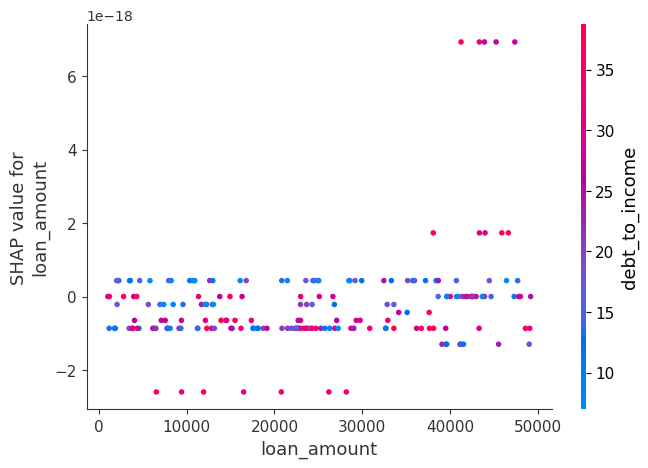

<Figure size 640x480 with 0 Axes>

In [13]:
# Plot dependence for top features
# get mean absolute shap per feature to determine top features
import numpy as np
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-6:][::-1]
top_features = X_test.columns[top_idx].tolist()
print('Top features by mean |SHAP|:', top_features)

for feat in top_features:
    plt.figure(figsize=(6,3))
    shap.dependence_plot(feat, shap_values, X_test, show=True)
    plt.tight_layout()
    plt.show()

## Local Explanation Example

True label: 0
Predicted proba: 3.906844017188967e-06


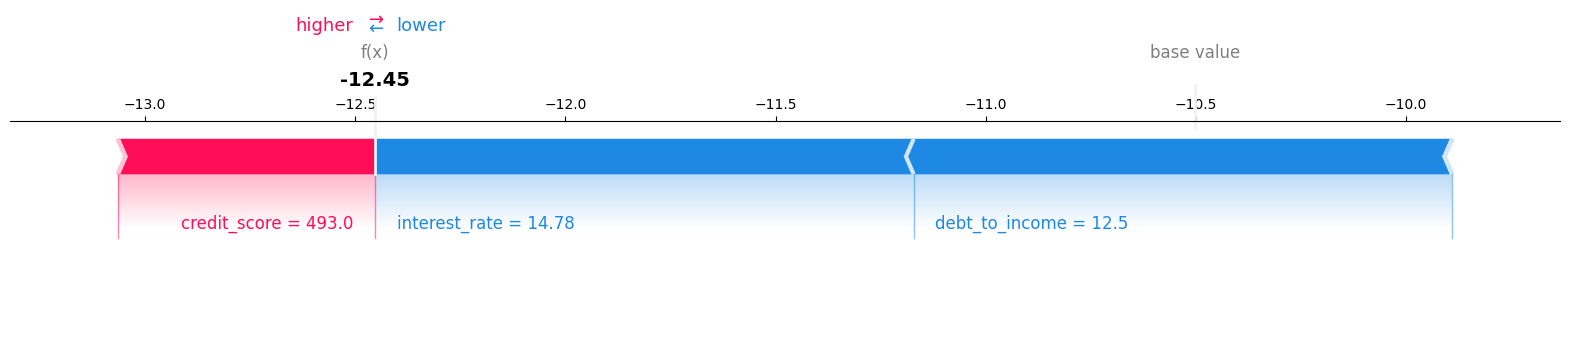

In [14]:
# Explain a single prediction from test set
i = 5
print('True label:', y_test.iloc[i])
print('Predicted proba:', model.predict_proba(X_test.iloc[[i]])[0,1])
shap.force_plot(explainer.expected_value, shap_values[i,:], X_test.iloc[i,:], matplotlib=True)

## Fairness / Segment Analysis

In [15]:
# Analyze default rates and model scores across income buckets and loan purpose
X_test_with = X_test.copy()
X_test_with['default'] = y_test.values
X_test_with['pred_proba'] = y_proba

# reconstruct annual_income (we used log) — if original column exists use it, otherwise estimate
if 'annual_income' in df2.columns:
    X_test_with['annual_income'] = np.expm1(X_test_with['annual_income_log'])
else:
    X_test_with['annual_income'] = df.loc[X_test_with.index, 'annual_income']

# income buckets
X_test_with['income_bucket'] = pd.qcut(X_test_with['annual_income'], q=4, labels=['low','med_low','med_high','high'])

# group stats
grouped = X_test_with.groupby('income_bucket').agg(
    true_rate=('default','mean'),
    pred_rate=('pred_proba','mean'),
    count=('default','size')
).reset_index()

grouped

/tmp/ipython-input-1509505325.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = X_test_with.groupby('income_bucket').agg(


,income_bucket,true_rate,pred_rate,count
0,low,0.08,0.08,50
1,med_low,0.10,0.10,50
2,med_high,0.08,0.08,50
3,high,0.08,0.08,50


## Executive Summary & Next Steps

**Executive summary (example):**

- The Gradient Boosting model achieves reasonable AUC on the synthetic dataset.
- SHAP global and local explanations identify the most important features affecting default risk (e.g., interest_rate, credit_score, debt_to_income).
- Fairness analysis by income buckets shows how predicted risk differs across segments — use this to inspect potential bias.
- Next steps: hyperparameter tuning, cross-validation, calibration, using real/representative data, and more robust fairness metrics (e.g., equal opportunity, demographic parity) on sensitive attributes.
